Total relations extracted: 38
[('detroit', 'sell', 'bonds'), ('efforts', 'roll', 'president'), ('voters', 'tend', 'welloff'), ('republicans', 'triumph', 'districts'), ('politicians', 'lead', 'creature'), ('shows', 'come', 'corruption'), ('england', 'reuter', 'carter'), ('experts', 'blame', 'hackers'), ('clinton', 'blame', 'russia'), ('lets', 'put', 'dc')]
Nodes: 73
Edges: 38

--- Centrality Measures ---
Top 5 by Degree Centrality:
experts: 0.0278
cuba: 0.0278
gop: 0.0278
detroit: 0.0139
bonds: 0.0139

Top 5 by Betweenness Centrality:
experts: 0.0004
cuba: 0.0004
gop: 0.0004
detroit: 0.0000
bonds: 0.0000

Top 5 by Closeness Centrality:
experts: 0.0278
cuba: 0.0278
gop: 0.0278
hackers: 0.0185
house: 0.0185

--- Communities ---
detroit -> Community 1
bonds -> Community 1
efforts -> Community 2
president -> Community 2
voters -> Community 4
welloff -> Community 4
republicans -> Community 7
districts -> Community 7
politicians -> Community 8
creature -> Community 8


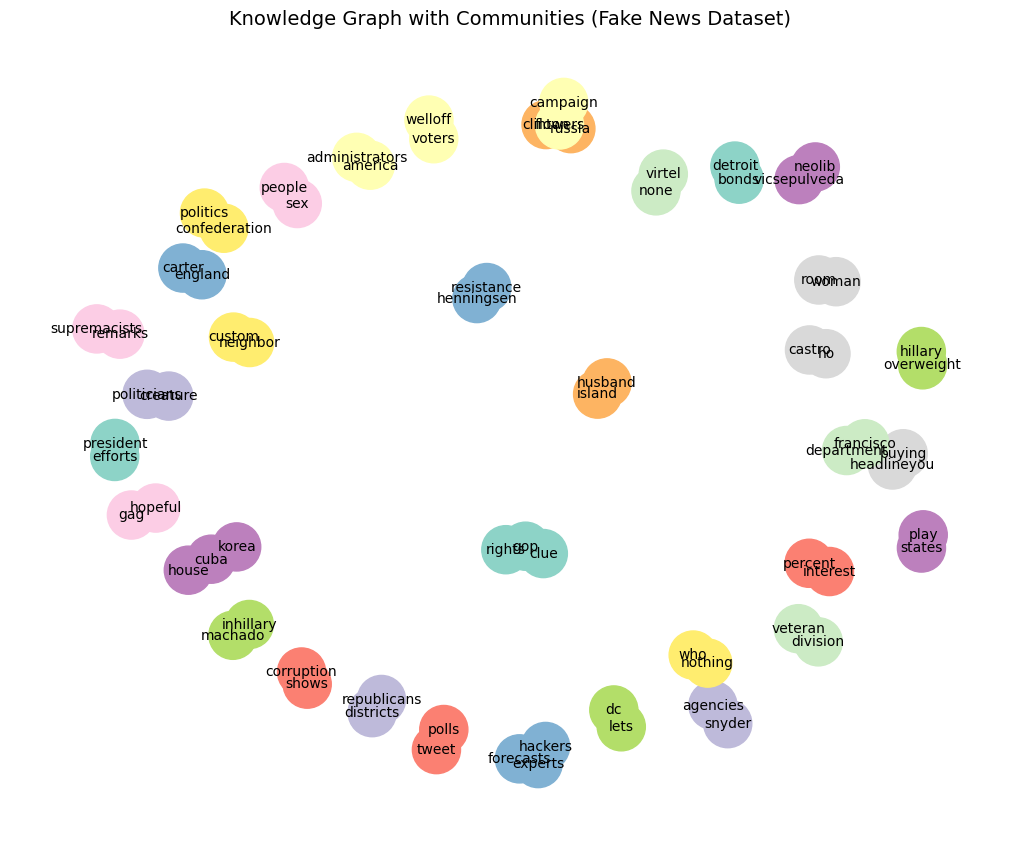

In [8]:
#Import Libraries
import spacy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain  # For Louvain community detection

#Load Model and Dataset
nlp = spacy.load("en_core_web_sm")
data = pd.read_csv("/content/Cleaned_FakeNews.csv")

# Use a small sample for visualization (optional)
# Filter out non-string values before sampling
sample_texts = data['text'].dropna().sample(40, random_state=42).tolist()

#Extract Relations (subject - verb - object)
def extract_relations(text):
    doc = nlp(text)
    relations = []
    for token in doc:
        if token.dep_ in ("ROOT", "relcl") and token.pos_ == "VERB":
            subject = [w.text for w in token.lefts if w.dep_ in ("nsubj", "nsubjpass")]
            obj = [w.text for w in token.rights if w.dep_ in ("dobj", "pobj")]
            if subject and obj:
                relations.append((subject[0], token.lemma_, obj[0]))
    return relations

# Collect all extracted relations
all_relations = []
for text in sample_texts:
    # Add a check to ensure the text is a string before processing
    if isinstance(text, str):
        all_relations.extend(extract_relations(text))
    else:
        print(f"Skipping non-string value: {text}")


print(f"Total relations extracted: {len(all_relations)}")
print(all_relations[:10])

#Step 1: Build Knowledge Graph
G = nx.Graph()

for head, relation, tail in all_relations:
    G.add_edge(head, tail, label=relation)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# 🔹 Step 2: Centrality Analysis
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Display top 5 entities by each centrality measure
print("\n--- Centrality Measures ---")
print("Top 5 by Degree Centrality:")
for node, cent in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

print("\nTop 5 by Betweenness Centrality:")
for node, cent in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

print("\nTop 5 by Closeness Centrality:")
for node, cent in sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{node}: {cent:.4f}")

#Step 3: Community Detection (Louvain Algorithm)
partition = community_louvain.best_partition(G)

print("\n--- Communities ---")
for node, community_id in list(partition.items())[:10]:
    print(f"{node} -> Community {community_id}")

#Step 4: Visualization
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Node colors based on community
colors = [partition[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=colors, cmap=plt.cm.Set3, node_size=1200, font_size=10)

# Draw edge labels (relations)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Knowledge Graph with Communities (Fake News Dataset)", fontsize=14)
plt.show()